TensorFlow Version : 2.21.0

Dataset Loaded Successfully

Training Images : (60000, 28, 28)
Training Labels : (60000,)

Testing Images : (10000, 28, 28)
Testing Labels : (10000,)

Image Size : (28, 28)

Number of Classes : 10

Class Names

0 : T-shirt
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle Boot


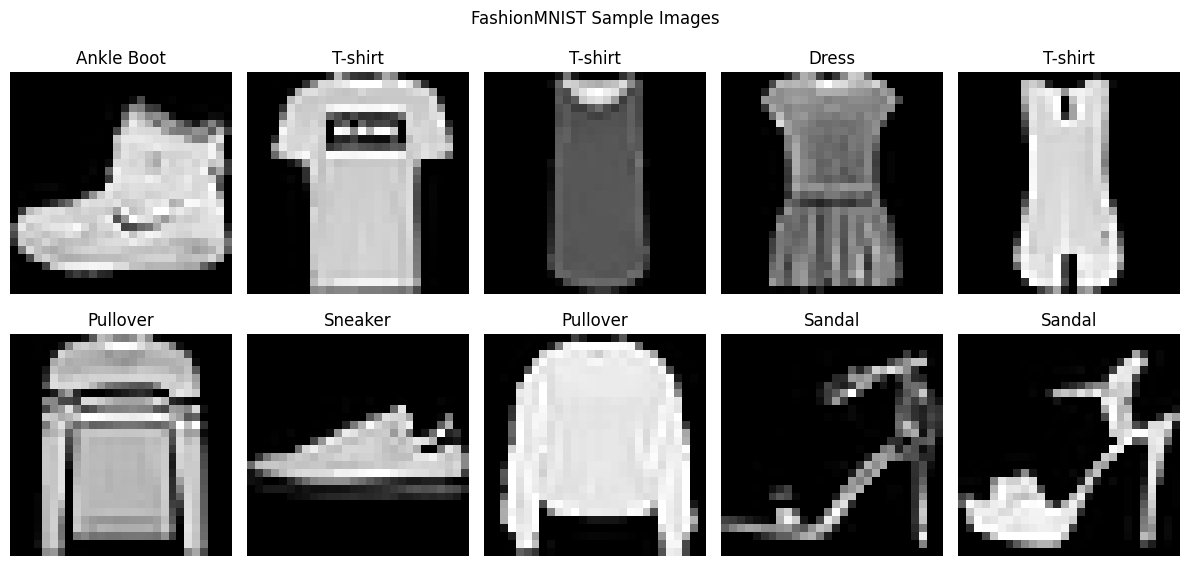

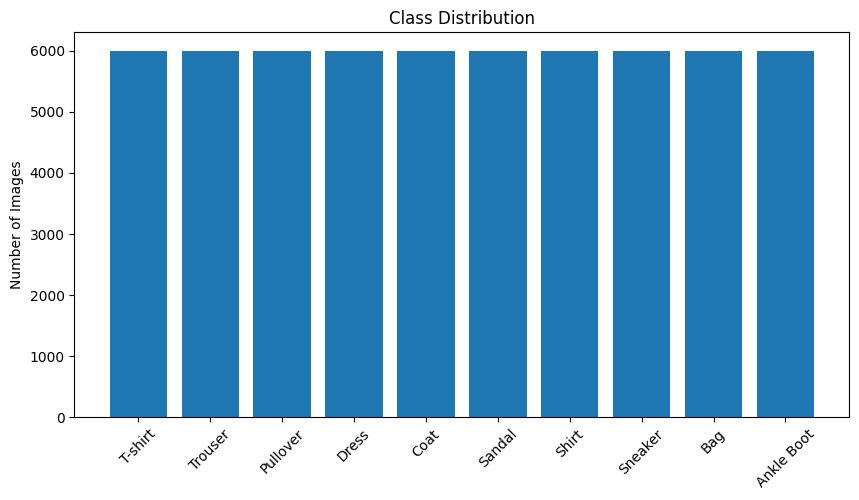


Preprocessing Dataset...

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)

Creating Data Augmentation Pipeline...


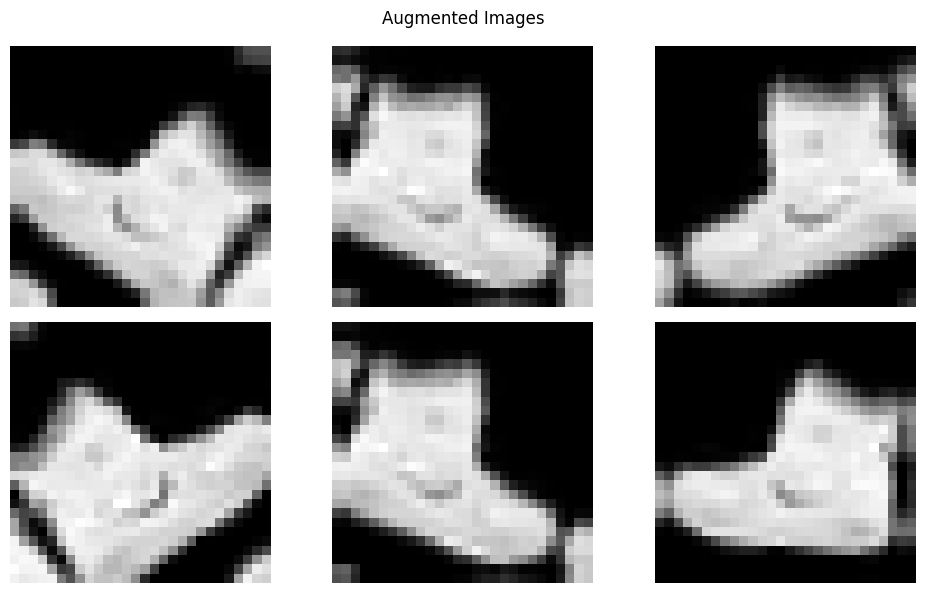


Building CNN Model...

CNN MODEL SUMMARY



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)            │ (1, 28, 28, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (1, 26, 26, 32)             │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (1, 13, 13, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (1, 11, 11, 64)             │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (1, 5, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (1, 3, 3, 128)              │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (1, 1152)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (1, 128)                    │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (1, 10)                     │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# ===========================
# Import Libraries
# ===========================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D,
                                     MaxPooling2D,
                                     Dense,
                                     Flatten,
                                     Dropout,
                                     RandomRotation,
                                     RandomFlip,
                                     RandomZoom)

from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau,
                                        ModelCheckpoint)

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             precision_score,
                             recall_score,
                             f1_score)

import random
import time

print("TensorFlow Version :", tf.__version__)

# ==========================================================
# Load Dataset
# ==========================================================

(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

print("\nDataset Loaded Successfully")

# ==========================================================
# Dataset Information
# ==========================================================

print("\nTraining Images :", train_x.shape)
print("Training Labels :", train_y.shape)

print("\nTesting Images :", test_x.shape)
print("Testing Labels :", test_y.shape)

print("\nImage Size :", train_x[0].shape)

print("\nNumber of Classes :", len(np.unique(train_y)))

# ==========================================================
# FashionMNIST Class Names
# ==========================================================

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print("\nClass Names\n")

for i, name in enumerate(class_names):
    print(i, ":", name)

# ==========================================================
# Display Sample Images
# ==========================================================

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(train_x[i], cmap="gray")

    plt.title(class_names[train_y[i]])

    plt.axis("off")

plt.suptitle("FashionMNIST Sample Images")

plt.tight_layout()

plt.show()

# ==========================================================
# Class Distribution
# ==========================================================

unique, counts = np.unique(train_y, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.xticks(rotation=45)

plt.ylabel("Number of Images")

plt.title("Class Distribution")

plt.show()

# ==========================================================
# Data Preprocessing
# ==========================================================

print("\nPreprocessing Dataset...")

# Normalize

train_x = train_x.astype("float32") / 255.0

test_x = test_x.astype("float32") / 255.0

# Reshape for CNN

train_x = train_x.reshape(-1,28,28,1)

test_x = test_x.reshape(-1,28,28,1)

print("\nTraining Shape :", train_x.shape)

print("Testing Shape :", test_x.shape)

# ==========================================================
# Data Augmentation
# ==========================================================

print("\nCreating Data Augmentation Pipeline...")

data_augmentation = Sequential([

    RandomRotation(0.10),

    RandomFlip("horizontal"),

    RandomZoom(0.10)

])

# ==========================================================
# Display Augmented Images
# ==========================================================

sample = train_x[0]

plt.figure(figsize=(10,6))

for i in range(6):

    augmented = data_augmentation(
        tf.expand_dims(sample,0)
    )

    plt.subplot(2,3,i+1)

    plt.imshow(tf.squeeze(augmented), cmap="gray")

    plt.axis("off")

plt.suptitle("Augmented Images")

plt.tight_layout()

plt.show()

# ==========================================================
# CNN MODEL
# ==========================================================

print("\nBuilding CNN Model...")

model = Sequential([

    data_augmentation,

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu"
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )

])

# ==========================================================
# Model Summary
# ==========================================================

print("\nCNN MODEL SUMMARY\n")

model.summary()



Model Compiled Successfully

Training Started...
Epoch 1/20
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8791 - loss: 0.3319
Epoch 1: val_accuracy improved from None to 0.87892, saving model to best_fashion_model.keras

Epoch 1: finished saving model to best_fashion_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8761 - loss: 0.3395 - val_accuracy: 0.8789 - val_loss: 0.3345 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8765 - loss: 0.3372
Epoch 2: val_accuracy did not improve from 0.87892
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8771 - loss: 0.3382 - val_accuracy: 0.8783 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 3/20
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8805 - loss: 0.3319
Epoch 3: val_accuracy did not improve from 0.87892
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8788 - loss: 0.3351 - val_accuracy: 0.8744 - val_loss: 0.3505 - learning_rate:

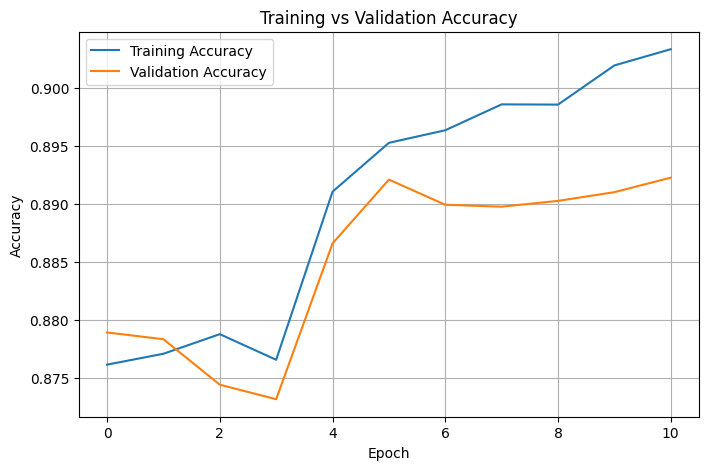

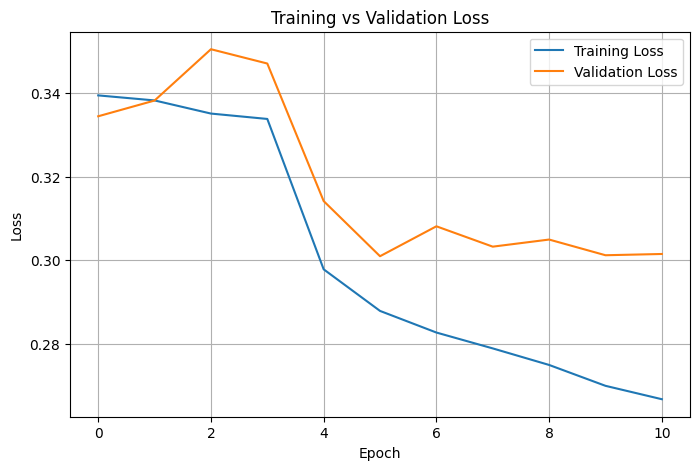

Hyperparameter Tuning

Training Model with Dropout = 0.3

Training Model with Dropout = 0.5

Hyperparameter Comparison
----------------------------------------
Dropout 0.3 --> Validation Accuracy : 0.9094
Dropout 0.5 --> Validation Accuracy : 0.9030

Best Dropout Rate : 0.3
Best Validation Accuracy : 0.909416675567627


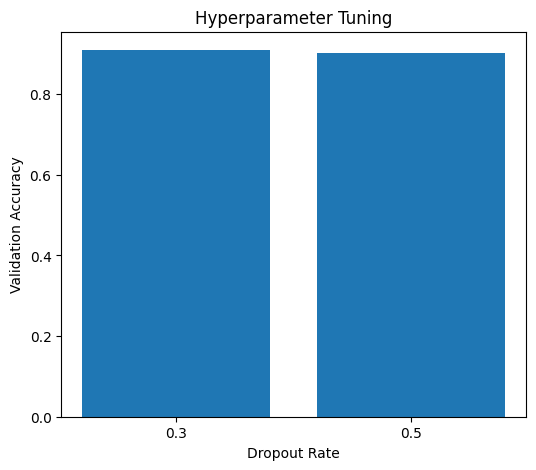

In [5]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel Compiled Successfully")

# ==========================================================
# Callbacks
# ==========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_fashion_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# ==========================================================
# Train Model
# ==========================================================

print("\nTraining Started...")

start_time = time.time()

history = model.fit(

    train_x,
    train_y,

    validation_split=0.20,

    epochs=20,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Completed")

print("\nTraining Time : {:.2f} seconds".format(training_time))

# ==========================================================
# Plot Accuracy
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# Plot Loss
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# Hyperparameter Tuning
# ==========================================================

print("="*60)
print("Hyperparameter Tuning")
print("="*60)

dropout_rates = [0.3,0.5]

results = {}

for rate in dropout_rates:

    print("\nTraining Model with Dropout =",rate)

    temp_model = Sequential([

        Conv2D(32,(3,3),
               activation="relu",
               input_shape=(28,28,1)),

        MaxPooling2D(),

        Conv2D(64,(3,3),
               activation="relu"),

        MaxPooling2D(),

        Conv2D(128,(3,3),
               activation="relu"),

        Flatten(),

        Dense(128,activation="relu"),

        Dropout(rate),

        Dense(10,activation="softmax")

    ])

    temp_model.compile(

        optimizer="adam",

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    temp_history = temp_model.fit(

        train_x,
        train_y,

        epochs=5,

        batch_size=32,

        validation_split=0.20,

        verbose=0

    )

    best_accuracy = max(temp_history.history["val_accuracy"])

    results[rate] = best_accuracy

# ==========================================================
# Print Comparison
# ==========================================================

print("\nHyperparameter Comparison")

print("-"*40)

for rate,acc in results.items():

    print(f"Dropout {rate} --> Validation Accuracy : {acc:.4f}")

best_dropout = max(results,key=results.get)

print("\nBest Dropout Rate :",best_dropout)

print("Best Validation Accuracy :",results[best_dropout])

# ==========================================================
# Hyperparameter Result Graph
# ==========================================================

plt.figure(figsize=(6,5))

plt.bar(
    [str(i) for i in results.keys()],
    list(results.values())
)

plt.xlabel("Dropout Rate")

plt.ylabel("Validation Accuracy")

plt.title("Hyperparameter Tuning")

plt.show()


Test Accuracy : 88.75 %
Test Loss : 0.3135

Precision : 0.8873
Recall : 0.8875
F1 Score : 0.8873

Classification Report

              precision    recall  f1-score   support

     T-shirt       0.83      0.84      0.84      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.82      0.85      0.83      1000
       Dress       0.89      0.90      0.89      1000
        Coat       0.81      0.81      0.81      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.67      0.64      0.65      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



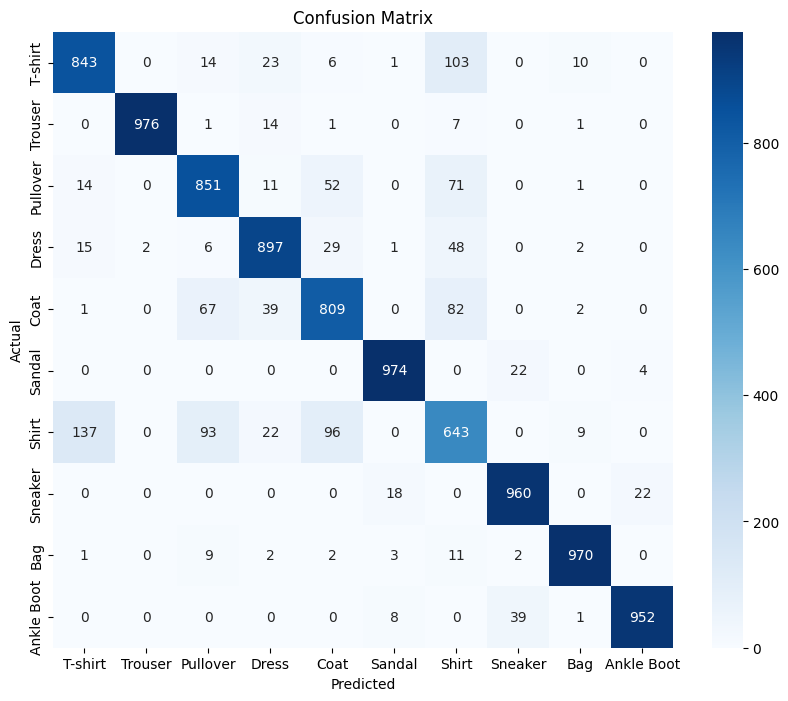

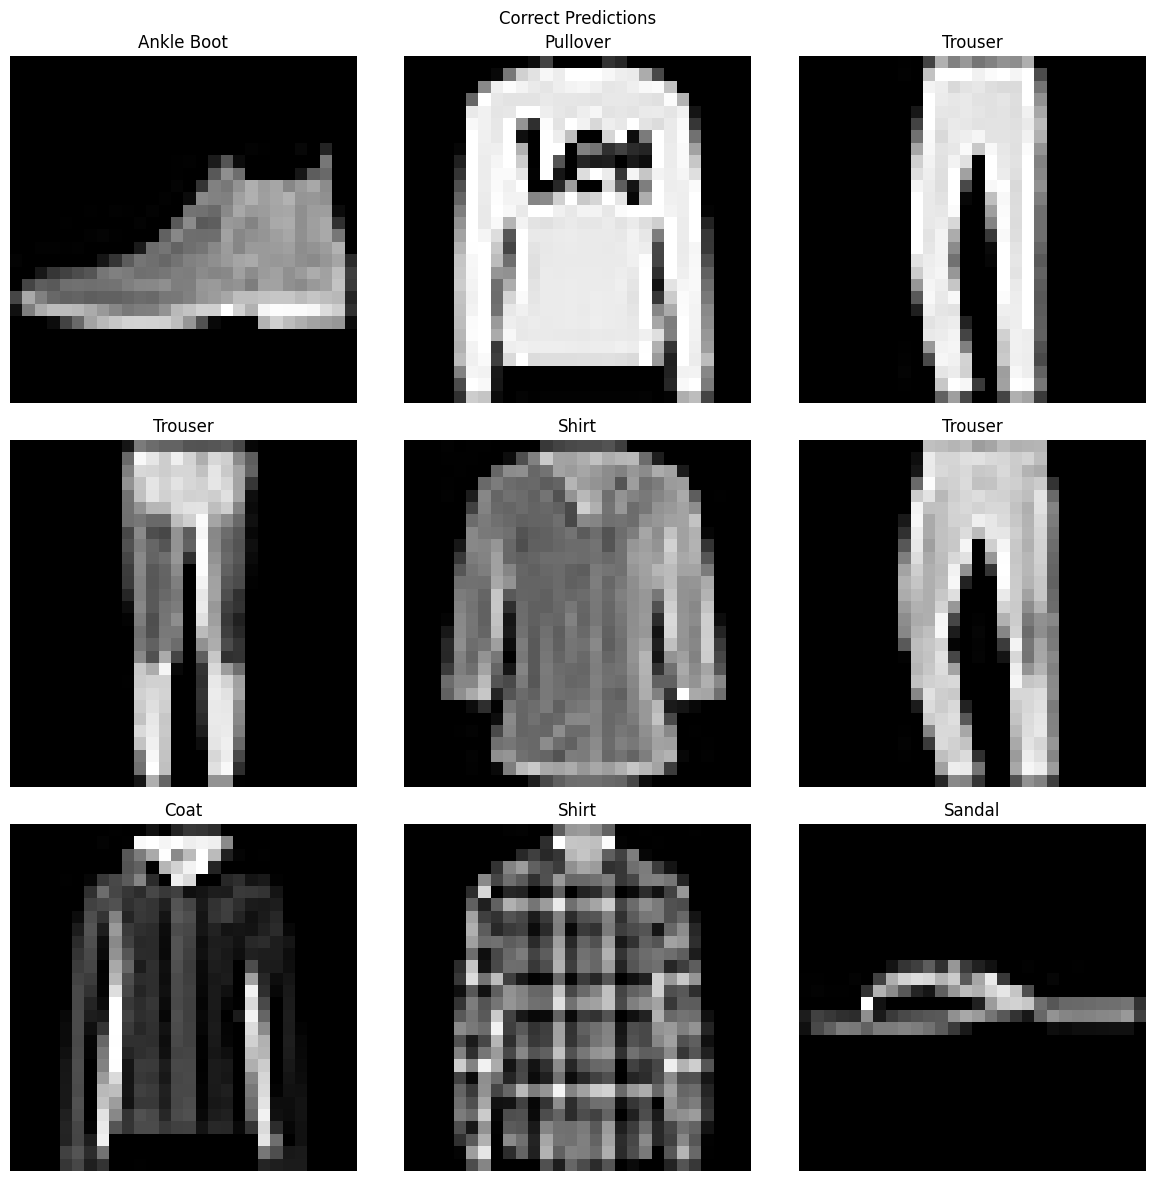

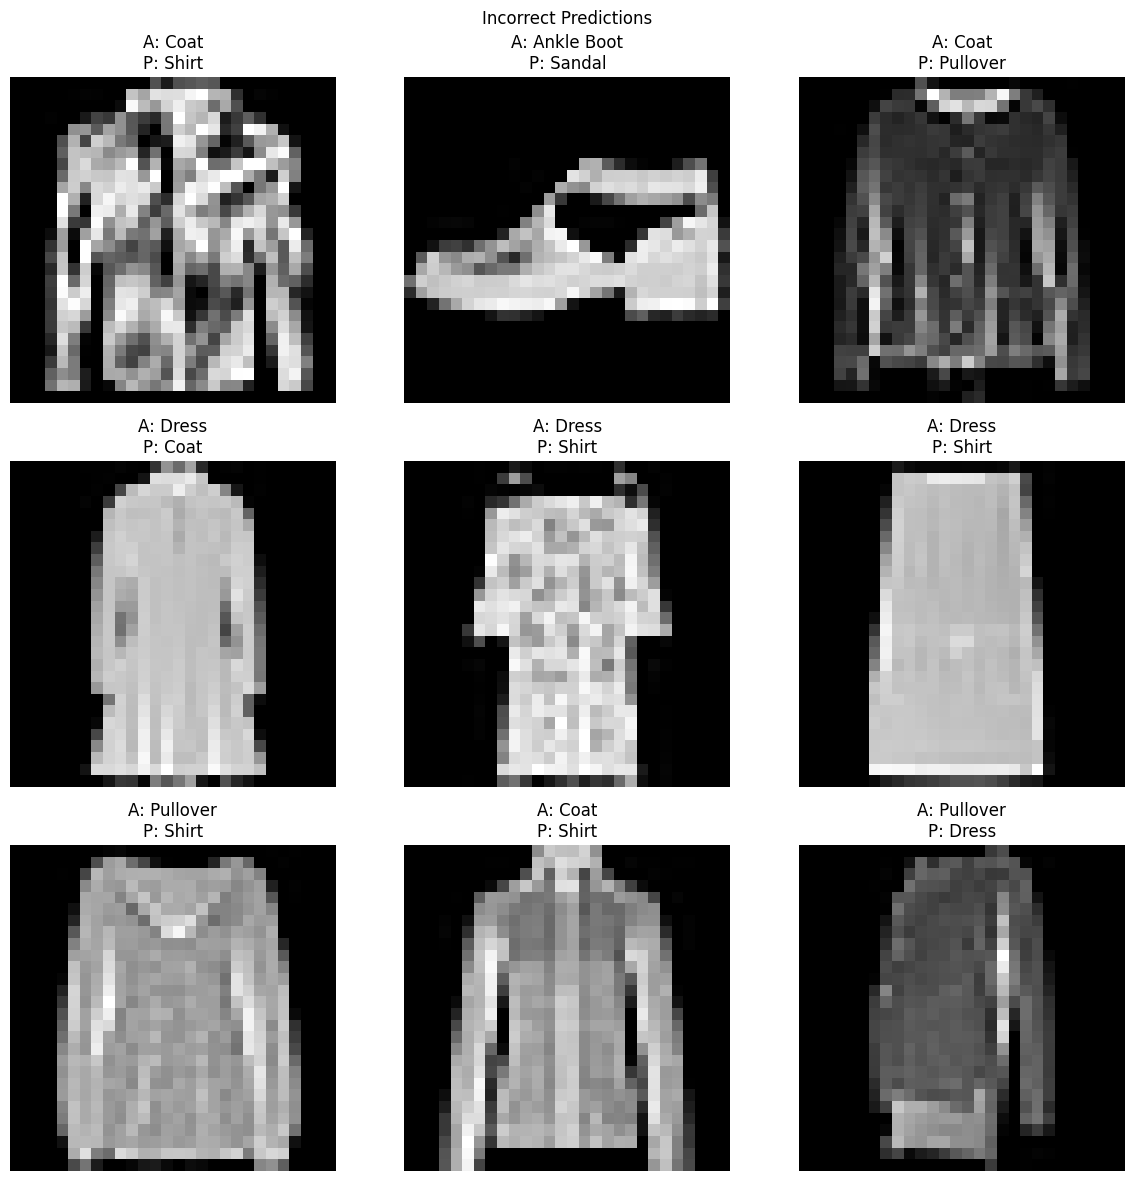

Predicting Random Test Images

Image 1
Actual Class : Dress


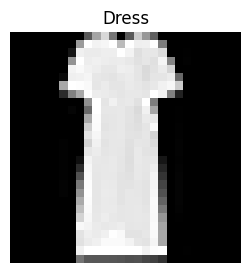

Predicted Class : Dress
Confidence : 99.99 %

Image 2
Actual Class : Trouser


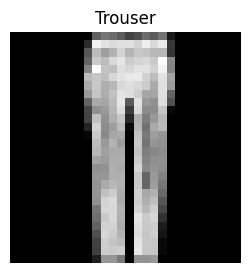

Predicted Class : Trouser
Confidence : 100.0 %

Image 3
Actual Class : Coat


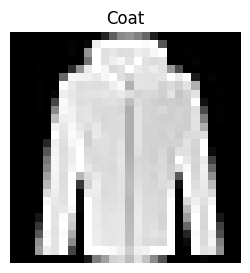

Predicted Class : Coat
Confidence : 98.9 %

Image 4
Actual Class : Bag


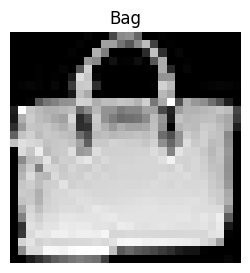

Predicted Class : Bag
Confidence : 100.0 %

Image 5
Actual Class : Sneaker


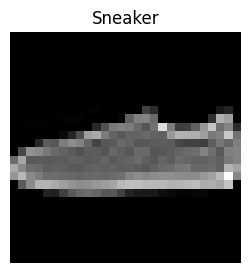

Predicted Class : Sneaker
Confidence : 99.77 %

Image 6
Actual Class : Ankle Boot


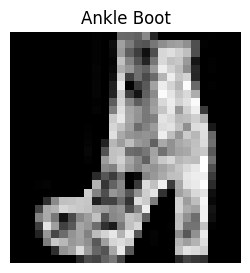

Predicted Class : Ankle Boot
Confidence : 99.77 %

Image 7
Actual Class : Trouser


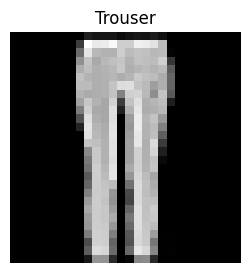

Predicted Class : Trouser
Confidence : 100.0 %

Image 8
Actual Class : Sandal


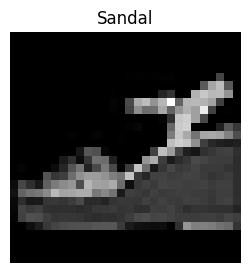

Predicted Class : Sandal
Confidence : 100.0 %

Image 9
Actual Class : Trouser


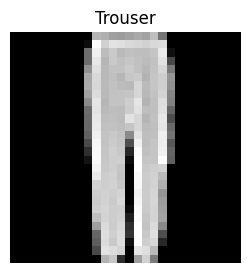

Predicted Class : Trouser
Confidence : 100.0 %

Image 10
Actual Class : Ankle Boot


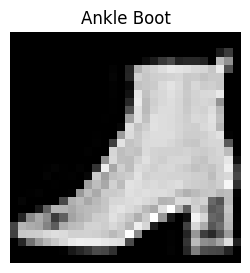

Predicted Class : Ankle Boot
Confidence : 99.99 %

Model Saved Successfully
Saved Model Loaded Successfully

Verification
Actual : Ankle Boot
Predicted : Ankle Boot


FINAL PROJECT SUMMARY
Training Images : 60000
Testing Images : 10000
Image Size : 28 x 28
Number of Classes : 10
Final Test Accuracy : 88.75%
Precision : 0.8873
Recall : 0.8875
F1 Score : 0.8873
Training Time : 301.73 Seconds
Total Parameters : 241546


In [6]:
# ==========================================================
# Evaluate Model
# ==========================================================

test_loss, test_accuracy = model.evaluate(test_x, test_y, verbose=0)

print("\nTest Accuracy :", round(test_accuracy * 100, 2), "%")
print("Test Loss :", round(test_loss, 4))

# ==========================================================
# Predictions
# ==========================================================

predictions = model.predict(test_x, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

# ==========================================================
# Evaluation Metrics
# ==========================================================

precision = precision_score(
    test_y,
    predicted_labels,
    average="weighted"
)

recall = recall_score(
    test_y,
    predicted_labels,
    average="weighted"
)

f1 = f1_score(
    test_y,
    predicted_labels,
    average="weighted"
)

print("\nPrecision :", round(precision,4))
print("Recall :", round(recall,4))
print("F1 Score :", round(f1,4))

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")

print(classification_report(
    test_y,
    predicted_labels,
    target_names=class_names
))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(test_y, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# Correct Predictions
# ==========================================================

correct = np.where(predicted_labels == test_y)[0]

plt.figure(figsize=(12,12))

for i,index in enumerate(correct[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(test_x[index].reshape(28,28),cmap="gray")

    plt.title(class_names[predicted_labels[index]])

    plt.axis("off")

plt.suptitle("Correct Predictions")

plt.tight_layout()

plt.show()

# ==========================================================
# Incorrect Predictions
# ==========================================================

wrong = np.where(predicted_labels != test_y)[0]

plt.figure(figsize=(12,12))

for i,index in enumerate(wrong[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(test_x[index].reshape(28,28),cmap="gray")

    plt.title(
        f"A: {class_names[test_y[index]]}\nP: {class_names[predicted_labels[index]]}"
    )

    plt.axis("off")

plt.suptitle("Incorrect Predictions")

plt.tight_layout()

plt.show()

# ==========================================================
# Prediction Function
# ==========================================================

def predict_image(image):

    image = image.reshape(1,28,28,1)

    prediction = model.predict(image,verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    plt.figure(figsize=(3,3))

    plt.imshow(image.reshape(28,28),cmap="gray")

    plt.axis("off")

    plt.title(class_names[predicted_class])

    plt.show()

    print("Predicted Class :",class_names[predicted_class])

    print("Confidence :",round(confidence*100,2),"%")

# ==========================================================
# Predict Random Images
# ==========================================================

print("="*60)

print("Predicting Random Test Images")

print("="*60)

for i in range(10):

    random_index = random.randint(0,len(test_x)-1)

    print("\nImage",i+1)

    print("Actual Class :",class_names[test_y[random_index]])

    predict_image(test_x[random_index])

# ==========================================================
# Save Model
# ==========================================================

model.save("fashion_mnist_image_tagging.keras")

print("\nModel Saved Successfully")

# ==========================================================
# Load Saved Model
# ==========================================================

loaded_model = tf.keras.models.load_model(
    "fashion_mnist_image_tagging.keras"
)

print("Saved Model Loaded Successfully")

# ==========================================================
# Verify Loaded Model
# ==========================================================

sample = test_x[0].reshape(1,28,28,1)

prediction = loaded_model.predict(sample,verbose=0)

pred = np.argmax(prediction)

print("\nVerification")

print("Actual :",class_names[test_y[0]])

print("Predicted :",class_names[pred])

# ==========================================================
# Final Performance Summary
# ==========================================================

print("\n")

print("="*70)

print("FINAL PROJECT SUMMARY")

print("="*70)

print("Training Images :",len(train_x))

print("Testing Images :",len(test_x))

print("Image Size : 28 x 28")

print("Number of Classes :",len(class_names))

print("Final Test Accuracy : {:.2f}%".format(test_accuracy*100))

print("Precision : {:.4f}".format(precision))

print("Recall : {:.4f}".format(recall))

print("F1 Score : {:.4f}".format(f1))

print("Training Time : {:.2f} Seconds".format(training_time))

print("Total Parameters :",model.count_params())
